<a href="https://colab.research.google.com/github/shathakshari2610/abc/blob/main/Copy_of_stock_price_prediction_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predict stock prices  with Long short-term memory (LSTM)

This simple example will show you how LSTM models predict time series data. Stock market data is a great choice for this because it's quite regular and widely available via the Internet.

## Install requirements
We install Tensorflow 2.0 with GPU support first

In [ ]:
!pip install tensorflow-gpu==2.0.0-alpha0

In [ ]:
!pip install pandas-datareader

In [ ]:
!apt install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [ ]:
!pip install pydot pydot-ng

## Introduction

LSTMs are very powerful in sequence prediction problems. They can store past information.

## Loading the dataset
I use pandas-datareader to get the historical stock prices from Yahoo! finance. For this example, I get only the historical data till the end of *training_end_data*.  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas_datareader import data
import yfinance as yf

In [ ]:
tickers = 'INFY.NS'

start_date = '2000-12-01'
end_date = '2018-12-31'

stock_data = yf.download(tickers, start_date, end_date)

[*********************100%***********************]  1 of 1 completed


In [ ]:
stock_data.head(10)

Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2000-12-01,74.489021,74.964782,72.063733,73.075548,54182464
2000-12-04,73.406212,74.802823,73.177786,74.710840,29766208
2000-12-05,73.397507,73.974957,72.373425,73.433278,43453632
2000-12-06,74.655632,77.674725,74.414431,77.674725,41569856
2000-12-07,74.473198,74.956110,73.893702,74.199803,23706944
2000-12-08,75.546341,75.821782,74.213093,74.213093,39107712
2000-12-11,76.343536,76.611821,75.242293,75.579564,39128768
2000-12-12,76.177444,77.470320,75.783961,76.448284,34921984


In [ ]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,9594.000000,9594.000000,9594.000000,9594.000000,9.594000e+03
mean,5.876595,5.933474,5.817562,5.877548,3.503355e+08
std,10.799629,10.892293,10.703899,10.800301,3.470619e+08
min,0.037773,0.038203,0.037773,0.038203,0.000000e+00
25%,0.218179,0.222939,0.214417,0.218248,1.361954e+08
50%,0.343015,0.349838,0.336512,0.343443,2.377956e+08
75%,5.442352,5.537372,5.349889,5.453487,4.367706e+08
max,55.161022,55.493789,54.616707,54.854403,7.421641e+09


In [ ]:
stock_data_len = stock_data['Close'].count()
print(stock_data_len)

Ticker
AAPL    9594
dtype: int64


I'm only interested in *close* prices

In [ ]:
close_prices = stock_data.iloc[:, 1:2].values
print(close_prices)

[[ 0.09915515]
 [ 0.09400455]
 [ 0.08713633]
 ...
 [37.50259572]
 [37.39288421]
 [37.81030598]]


Of course, some of the weekdays might be public holidays in which case no price will be available. For this reason, we will fill the missing prices with the latest available prices

In [ ]:
all_bussinessdays = pd.date_range(start=start_date, end=end_date, freq='B')
print(all_bussinessdays)

DatetimeIndex(['1980-12-01', '1980-12-02', '1980-12-03', '1980-12-04',
               '1980-12-05', '1980-12-08', '1980-12-09', '1980-12-10',
               '1980-12-11', '1980-12-12',
               ...
               '2018-12-18', '2018-12-19', '2018-12-20', '2018-12-21',
               '2018-12-24', '2018-12-25', '2018-12-26', '2018-12-27',
               '2018-12-28', '2018-12-31'],
              dtype='datetime64[ns]', length=9936, freq='B')


In [ ]:
close_prices = stock_data.reindex(all_bussinessdays)
close_prices = stock_data.fillna(method='ffill')

<ipython-input-15-218da55dd8bc>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close_prices = stock_data.fillna(method='ffill')


In [ ]:
close_prices.head(10)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
1980-12-12,0.098726,0.099155,0.098726,0.098726,469033600
1980-12-15,0.093575,0.094005,0.093575,0.094005,175884800
1980-12-16,0.086707,0.087136,0.086707,0.087136,105728000
1980-12-17,0.088853,0.089282,0.088853,0.088853,86441600
1980-12-18,0.091429,0.091858,0.091429,0.091429,73449600
1980-12-19,0.097009,0.097438,0.097009,0.097009,48630400
1980-12-22,0.101730,0.102160,0.101730,0.101730,37363200
1980-12-23,0.106023,0.106453,0.106023,0.106023,46950400


The dataset is now complete and free of missing values. Let's have a look to the data frame summary:

## Feature scaling

In [ ]:
training_set = close_prices.iloc[:, 1:2].values

In [ ]:
print(training_set)

[[ 0.09915515]
 [ 0.09400455]
 [ 0.08713633]
 ...
 [37.50259572]
 [37.39288421]
 [37.81030598]]


In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)
print(training_set_scaled.shape)

(9594, 1)


LSTMs expect the data in a specific format, usually a 3D tensor. I start by creating data with 60 days and converting it into an array using NumPy. Next, I convert the data into a 3D dimension array with feature_set samples, 60 days and one feature at each step.

In [ ]:
features = []
labels = []
for i in range(60,len(stock_data)):
    features.append(training_set_scaled[i-60:i, 0])
    labels.append(training_set_scaled[i, 0])

features = np.array(features)
labels = np.array(labels)

features = np.reshape(features, (features.shape[0], features.shape[1], 1))

In [ ]:
print(labels)

[6.65666228e-04 7.12105091e-04 6.96625702e-04 ... 6.75574741e-01
 6.73596374e-01 6.81123511e-01]


In [ ]:
print(features)

[[[1.09912421e-03]
  [1.00624625e-03]
  [8.82395445e-04]
  ...
  [9.13355286e-04]
  [7.81777596e-04]
  [7.12105091e-04]]

 [[1.00624625e-03]
  [8.82395445e-04]
  [9.21095033e-04]
  ...
  [7.81777596e-04]
  [7.12105091e-04]
  [6.65666228e-04]]

 [[8.82395445e-04]
  [9.21095033e-04]
  [9.67546799e-04]
  ...
  [7.12105091e-04]
  [6.65666228e-04]
  [7.12105091e-04]]

 ...

 [[9.67296628e-01]
  [9.82641108e-01]
  [9.85127213e-01]
  ...
  [6.96564315e-01]
  [6.79574766e-01]
  [6.51144631e-01]]

 [[9.82641108e-01]
  [9.85127213e-01]
  [1.00000000e+00]
  ...
  [6.79574766e-01]
  [6.51144631e-01]
  [6.75574741e-01]]

 [[9.85127213e-01]
  [1.00000000e+00]
  [9.95199614e-01]
  ...
  [6.51144631e-01]
  [6.75574741e-01]
  [6.73596374e-01]]]


Feature tensor with three dimension: features[0] contains the ..., features[1] contains the last 60 days of values and features [2] contains the  ...

In [ ]:
print(features.shape)

(9534, 60, 1)


## Create the LSTM network
Let's create a sequenced LSTM network with 50 units. Also the net includes some dropout layers with 0.2 which means that 20% of the neurons will be dropped.

In [ ]:
import tensorflow as tf

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(units = 50, return_sequences = True, input_shape = (features.shape[1], 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(units = 50, return_sequences = True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(units = 50, return_sequences = True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(units = 50),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units = 1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#tf.keras.utils.plot_model(model, to_file='my_model.png')


In [ ]:
# Run tensorboard with the logdir
#import os
#LOG_BASE_DIR = './log'
#os.makedirs(LOG_BASE_DIR, exist_ok=True)

In [ ]:
#!ls -l log

## Load the Colab TensorBoard extention and start TensorBoard inline

In [ ]:
#%load_ext tensorboard.notebook
#%tensorboard --logdir {LOG_BASE_DIR}

## Define a TensorBoard callback

In [ ]:
#import datetime
#logdir = os.path.join(LOG_BASE_DIR, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

In [ ]:
#from tensorflow.keras.callbacks import TensorBoard

#tbCallBack = TensorBoard(logdir,histogram_freq=1)

The model will be compiled and optimize by the adam optimizer and set the loss function as mean_squarred_error

In [ ]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [ ]:
#import os
#print(os.environ)

In [ ]:
#tf.test.gpu_device_name()

In [ ]:
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

In [ ]:
from time import time
start = time()
history = model.fit(features, labels, epochs = 20, batch_size = 32, verbose = 1)
end = time()

Epoch 1/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0031
Epoch 2/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 6.7330e-04
Epoch 3/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 6.1078e-04
Epoch 4/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5.7557e-04
Epoch 5/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5.9692e-04
Epoch 6/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 6.7715e-04
Epoch 7/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 4.8082e-04
Epoch 8/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 4.9123e-04
Epoch 9/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 4.7796e-04
Epoch 10/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 6.0636e-04
Epoch 11/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 4.2776e-04
Epoch 12/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 5.3048e-04
Epoch 13/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 4.5639e-04
Epoch 14/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 3

In [ ]:
print('Total training time {} seconds'.format(end - start))

Total training time 101.32863140106201 seconds


In [ ]:
#  [samples, days, features]
print(features.shape)

(9534, 60, 1)


In [ ]:
testing_start_date = '2019-01-01'
testing_end_date = '2019-04-10'

test_stock_data = yf.download(tickers, testing_start_date, testing_end_date)

[*********************100%***********************]  1 of 1 completed


In [ ]:
test_stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-04-03,46.794857,47.070331,46.267858,46.291814,93087200
2019-04-04,46.876286,47.039173,46.265449,46.660694,76457200
2019-04-05,47.190098,47.214054,46.933784,47.058348,74106400
2019-04-08,47.932678,47.963816,47.031992,47.051156,103526800
2019-04-09,47.788948,48.591421,47.724270,47.985376,143072800


In [ ]:
test_stock_data_processed = test_stock_data.iloc[:, 1:2].values


In [ ]:
print(test_stock_data_processed.shape)

(68, 1)


In [ ]:
all_stock_data = pd.concat((stock_data['Close'], test_stock_data['Close']), axis = 0)

In [ ]:
inputs = all_stock_data[len(all_stock_data) - len(test_stock_data) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [ ]:
X_test = []
for i in range(60, 129):
    X_test.append(inputs[i-60:i, 0])

In [ ]:
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = model.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step


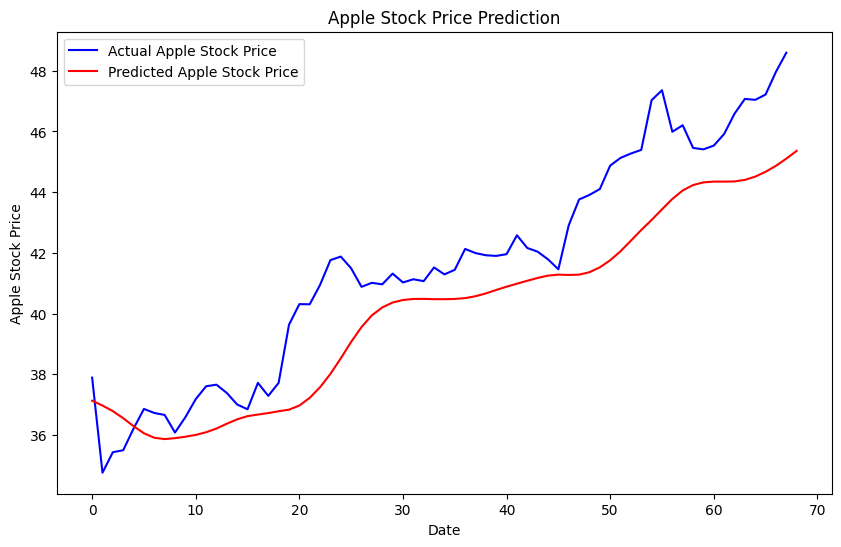

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(test_stock_data_processed, color='blue', label='Actual Apple Stock Price')
plt.plot(predicted_stock_price , color='red', label='Predicted Apple Stock Price')
plt.title('Apple Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Apple Stock Price')
plt.legend()
plt.show()

In [ ]:
#inputs = inputs.reshape(-1,1)
#inputs = sc.transform(inputs)


test_inputs = test_stock_data_processed.reshape(-1,1)
test_inputs = sc.transform(test_inputs)


print(test_inputs.shape)

(68, 1)


In [ ]:
test_features = []
for i in range(60, len(test_inputs)):
    test_features.append(test_inputs[i-60:i, 0])

test_features = np.array(test_features)

In [ ]:
test_features = np.reshape(test_features, (test_features.shape[0], test_features.shape[1], 1))
print(test_features.shape)

(8, 60, 1)


In [ ]:
predicted_stock_price = model.predict(test_features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [ ]:
predicted_stock_price = sc.inverse_transform(predicted_stock_price)
print(predicted_stock_price.shape)

(8, 1)


In [ ]:
print(test_stock_data_processed.shape)

(68, 1)


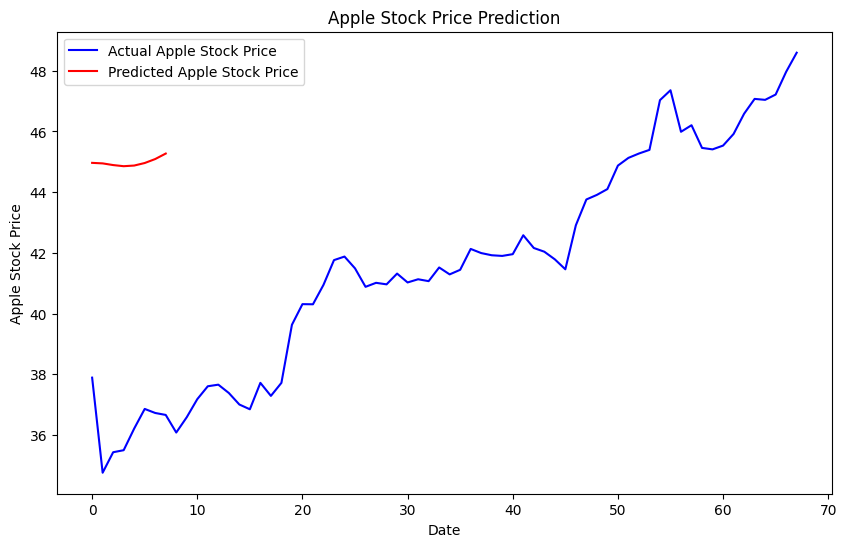

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(test_stock_data_processed, color='blue', label='Actual Apple Stock Price')
plt.plot(predicted_stock_price , color='red', label='Predicted Apple Stock Price')
plt.title('Apple Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Apple Stock Price')
plt.legend()
plt.show()

## Download the model and the weights

In [ ]:
from google.colab import files

In [ ]:
model_json = model.to_json()
with open("model.json", "w") as json_file:
  json_file.write(model_json)

In [ ]:
files.download("model.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save('weights.h5')
files.download('weights.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>